In [1]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


## Tidied up MLP w/ He optimisation, batch norm, and a few other imporvements

In [3]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [4]:
# MLP revisited
n_embd   = 10  # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # He initialisation (pytorch also has an implementation)
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01 # fix tanh layer too saturated | batch norm makes adding bias before pointless
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # fix soft max confidently wrong
b2 = torch.randn(vocab_size,                      generator=g) * 0    # fix soft max confidently wrong

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [5]:
# train only on the training data Xtr, Ytr
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  # mini batch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]                          # (N, block_size, n_embd)
  emb_cat = emb.view(emb.shape[0], -1) # concat to (N, block_size * n_embd)
  # linear layer
  hpreact = emb_cat @ W1 #+ b1 -> no need for bias in layer before batch norm layer as -bnmean removes it and its replaced by bnbias
  # ------
  # BatchNorm layer
  bnmeani = hpreact.mean(0, keepdim=True) # mini-batch mean
  bnstdi = hpreact.mean(0, keepdim=True)  # mini-batch std
  hpreact = bngain*(hpreact-bnmeani)/bnstdi + bnbias
  with torch.no_grad(): # done on the side of training
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani # update running mean slightly
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # ------
  # non-linear layer
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2                 # (N, vocab_size)
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01 # step lr decay
  for p in parameters:
    p.data += - lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i: 7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.2838
  10000/ 200000: 2.1659
  20000/ 200000: 2.4716
  30000/ 200000: 1.9498
  40000/ 200000: 2.2199
  50000/ 200000: 1.8842
  60000/ 200000: 2.0894
  70000/ 200000: 2.2332
  80000/ 200000: 2.3577
  90000/ 200000: 2.1024
 100000/ 200000: 2.3491
 110000/ 200000: 2.2102
 120000/ 200000: 1.6894
 130000/ 200000: 1.9457
 140000/ 200000: 2.2470
 150000/ 200000: 1.9071
 160000/ 200000: 2.1174
 170000/ 200000: 2.4515
 180000/ 200000: 2.0307
 190000/ 200000: 2.1175


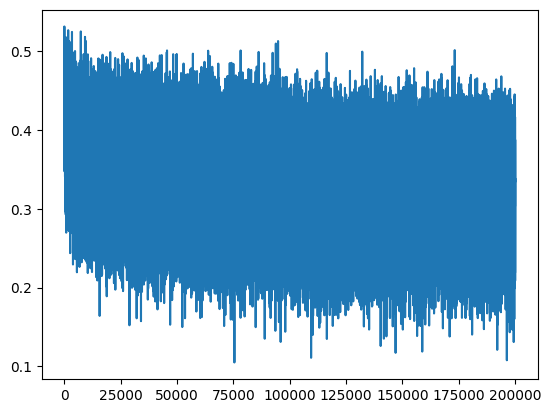

In [6]:
plt.plot(lossi)

In [7]:
# After adding batch norm, the layer's output depends on batch statistics
# (the mean and standard deviation of the current mini-batch).
#
# During training, this batch-to-batch variation acts as a mild source of noise,
# which can have a useful regularizing effect.
#
# At evaluation time (validation / test / deployment), however, we usually want
# deterministic behavior. If we keep using the current batch statistics, the model's
# outputs and loss will depend on which examples happen to be grouped together.
#
# To avoid this, we estimate "running" / fixed batch-norm statistics from the training
# set after training, and use those fixed values at inference time.

'''
with torch.no_grad():
    emb = C[Xtr]
    emb_cat = emb.view(emb.shape[0], -1)
    hpreact = emb_cat @ W1 + b1  # pre-activation of hidden layer

    bnmean = hpreact.mean(0, keepdim=True)                 # feature-wise mean
    bnstd = hpreact.std(0, keepdim=True, unbiased=False)   # feature-wise std
'''

# this works but is annoying to have to do afterwards like here so we instead do it during the training
print()

In [8]:
@torch.no_grad() # disables grad tracking as we don't need it anymore because no more backward passes

def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    emb_cat = emb.view(emb.shape[0], -1)
    hpreact = emb_cat @ W1 #+ b1 # hidden layer
    # ------
    # Batch norm layer
    hpreact = bngain*(hpreact-bnmean_running)/bnstd_running + bnbias
    # ------
    h = torch.tanh(hpreact)

    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, round(loss.item(), 4))

split_loss('train')
split_loss('val')

train 2.079
val 2.1214


## Log
Note that we don't expect these issues to be too significant as the network is so shallow (only 1 hidden layer).

original:\
train 2.1268
val 2.1698

fix softmax confidently wrong at init:\
train 2.0696
val 2.1311

fix tanh layer too saturated at init (could result in dead neurons):\
train 2.0356
val 2.1027

Using He optimisation of W1:\
train 2.0377
val 2.107

NNs used to be very sensitive to the initialisation but newer developments such as batch normalisation, Adam (adaptive gradient), gradient momentum, regularisation made nn, especially dnns, much more stable to train and therefore less sensitive to initialisation.

batch norm:\
train 2.0831
val 2.1219

batch norm w/ running calcs:\
train 2.079
val 2.1214

In [9]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    emb = C[torch.tensor([context])]
    hpreact = emb.view(emb.shape[0], -1) @ W1
    hpreact = bngain*(hpreact-bnmean_running)/bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))

carlah.
amorie.
khi.
mri.
reet.
khalaysie.
mahnen.
delynn.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
join.
quintis.
lilea.
jadiquinterri.
jarynix.
kaellissa.
med.


## A deeper & pytorch-ified NN

In [10]:
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps # to prevent div zero error for layers with no variance
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
    
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# tanh class to enable building layers in a clean way, just implement torch.tanh
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ] # 6 layer MLP wo/ batchnorm - very sensitive to initialised gain value!

layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
] # 6 layer MLP w/ batchnorm - initialised gain value is not that important anymore and it converges well regardless

with torch.no_grad():
  # last layer: make less confident
  #layers[-1].weight *= 0.1
  layers[-1].gamma *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [11]:
# train only on the training data Xtr, Ytr
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # update:data ratio

for i in range(max_steps):
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb)

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.05 if i < 100000 else 0.005 # step lr decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i: 7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
  
  #if i >= 5000:
  #  break # AFTER DEBUG: would take out obviously to run full optimization


      0/ 200000: 3.2870
  10000/ 200000: 2.3766
  20000/ 200000: 2.1700
  30000/ 200000: 2.0638
  40000/ 200000: 2.1383
  50000/ 200000: 2.2710
  60000/ 200000: 1.7603
  70000/ 200000: 2.2075
  80000/ 200000: 2.2513
  90000/ 200000: 1.9034
 100000/ 200000: 2.5026
 110000/ 200000: 2.1866
 120000/ 200000: 2.1629
 130000/ 200000: 2.0475
 140000/ 200000: 1.6819
 150000/ 200000: 1.9254
 160000/ 200000: 2.0484
 170000/ 200000: 1.9513
 180000/ 200000: 2.2813
 190000/ 200000: 1.9705


layer 2 (      Tanh): mean -0.01, std 0.66, saturated: 9.41%
layer 5 (      Tanh): mean +0.00, std 0.69, saturated: 12.12%
layer 8 (      Tanh): mean +0.00, std 0.72, saturated: 11.03%
layer 11 (      Tanh): mean -0.01, std 0.73, saturated: 10.00%
layer 14 (      Tanh): mean -0.01, std 0.75, saturated: 10.38%


/var/folders/k7/7f0961gd3k1dv8fjb6pj_5340000gp/T/ipykernel_42853/596179119.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

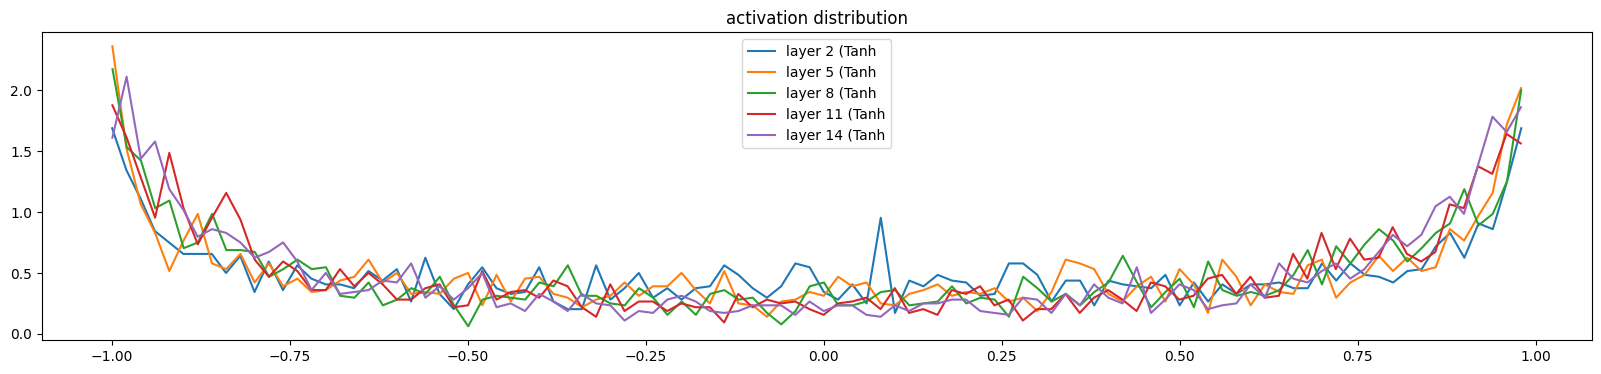

In [12]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer as its just a softmax
  if isinstance(layer, Tanh):
    t = layer.out
    # defined satureated as t.abs>0.97 as values close to 1 will stop gradients from flowing backwards
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 4.985882e-03
layer 5 (      Tanh): mean +0.000000, std 4.357022e-03
layer 8 (      Tanh): mean -0.000000, std 4.148110e-03
layer 11 (      Tanh): mean -0.000000, std 4.353823e-03
layer 14 (      Tanh): mean -0.000000, std 4.232156e-03


Text(0.5, 1.0, 'gradient distribution')

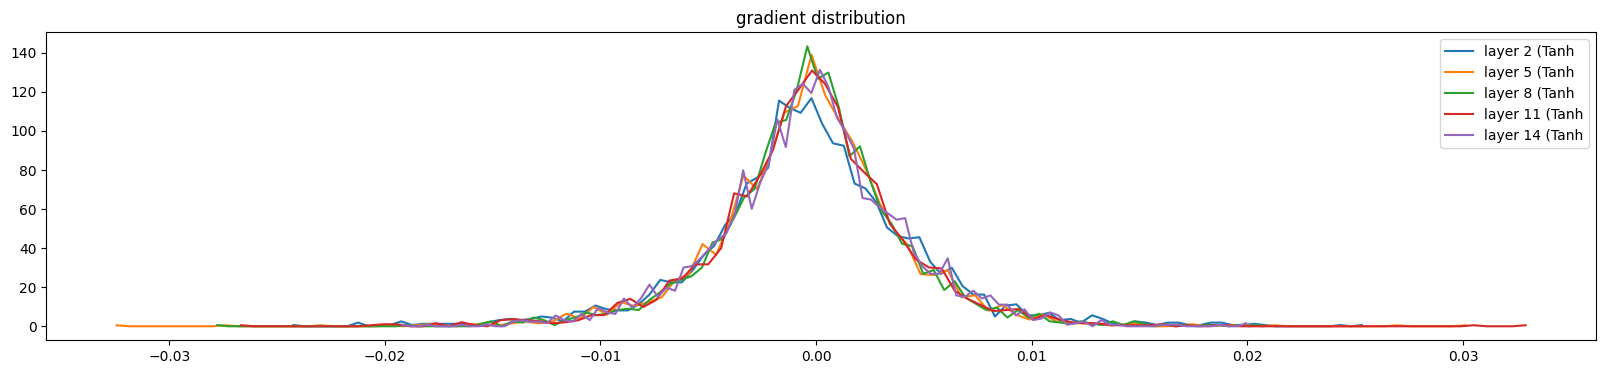

In [13]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.762255e-02 | grad:data ratio 1.717124e-02
weight  (30, 100) | mean -0.000010 | std 1.185957e-02 | grad:data ratio 3.365482e-02
weight (100, 100) | mean +0.000011 | std 8.180026e-03 | grad:data ratio 3.961796e-02
weight (100, 100) | mean -0.000199 | std 7.912559e-03 | grad:data ratio 3.878531e-02
weight (100, 100) | mean +0.000028 | std 7.547258e-03 | grad:data ratio 3.747003e-02
weight (100, 100) | mean +0.000041 | std 6.958795e-03 | grad:data ratio 3.526806e-02
weight  (100, 27) | mean +0.000254 | std 1.276467e-02 | grad:data ratio 5.057529e-02


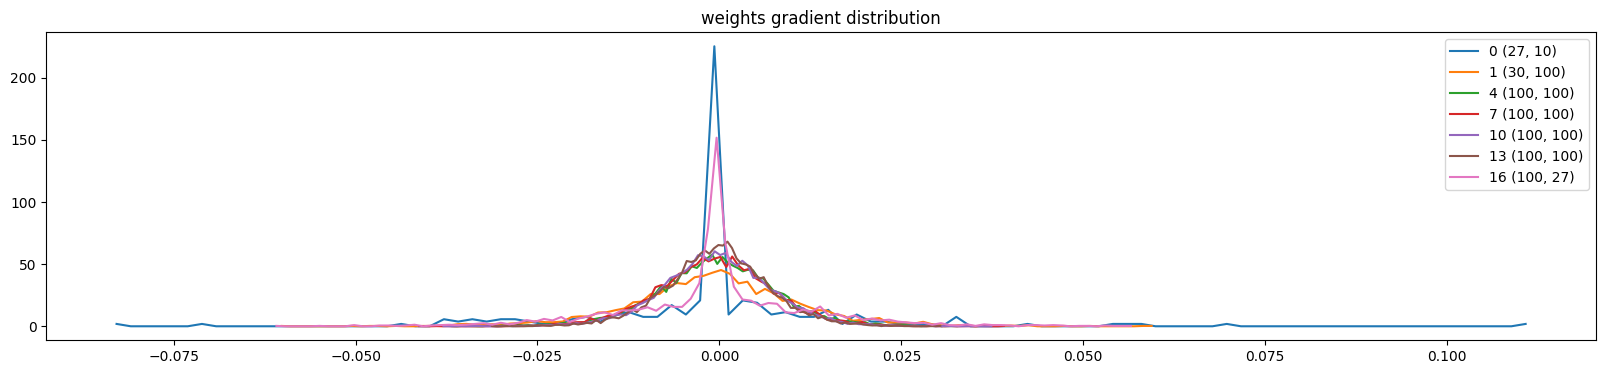

In [14]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # means we just get the weights
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

# grad:data is useful for efficient learning (not too small) and ensuring convergence (not too big)
# update:data ratio is actually what we care about but grad:data allows us to get an idea ofr what our lr should be

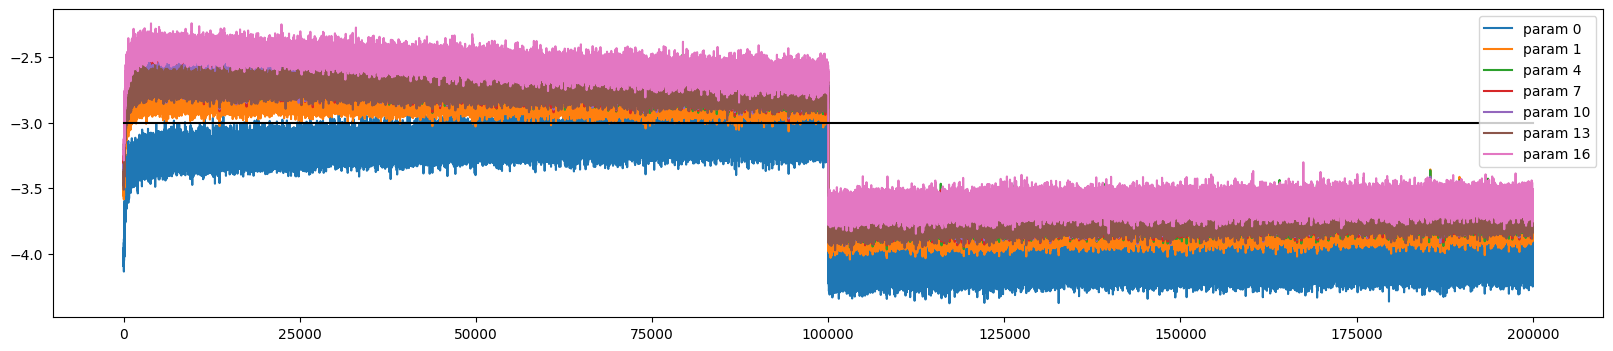

In [15]:
# update:data ratio -> gives you an idea of if your lr is suitable
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be roughly ~1e-3 (-3 on log plot)
plt.legend(legends);

In [16]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.0249123573303223
val 2.0892276763916016


In [17]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carlah.
amelle.
khyimrix.
tatya.
kanden.
jazonte.
deliah.
jareei.
nellara.
chaiivia.
legend.
bron.
catessan.
shon.
raiviani.
wavero.
dearyxia.
kael.
dus.
brex.
